In [278]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os
import warnings
import json

import numpy as np

def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),  # min of both axes
        np.max([ax.get_xlim(), ax.get_ylim()]),  # max of both axes
    ]

    # now plot both limits against eachother
    ax.plot(lims, lims, c="k", alpha=0.75, zorder=0)
    ax.set(**{"aspect": "equal", "xlim": lims, "ylim": lims})
    return ax

# Suppress warnings
warnings.simplefilter(action='ignore', category=Warning)

fsize = 15
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'

In [3]:
def load_evidence(fn, ds_name):
    # we only want derived since we're going to compare gene ids
    df = pd.read_json(fn)
    ddf = df['derived'].apply(pd.Series)
    ddf["ds_name"] = ds_name

    # normalize the string values for cell types
    ddf["cell_type_label"] = ddf["cell_type_label"].str.strip().str.upper()
    ddf["cell_type_id"] = ddf["cell_type_id"].str.strip().str.upper()
    
    # normalize the string values for genes
    ddf["feature_name"] = ddf["feature_name"].str.strip().str.upper()
    ddf["feature_identifier"] = ddf["feature_identifier"].str.strip().str.upper()
    hddf = ddf.query("organism == 'homo_sapiens'")
    return hddf

In [4]:
hmn_fns = glob.glob("../../data/*/evidence_human/evidence.json")
deg_fns = glob.glob("../../data/*/evidence_deg/evidence.json")

In [58]:
hmn_dfs = []
for fn in hmn_fns:
    tmp = load_evidence(fn, fn.split("/")[-3])
    hmn_dfs.append(tmp)

hmn = pd.concat(hmn_dfs).dropna(subset=["cell_type_id", "feature_identifier"])

deg_dfs = []
for fn in deg_fns:
    tmp = load_evidence(fn, fn.split("/")[-3])
    deg_dfs.append(tmp)

deg = pd.concat(deg_dfs).dropna(subset=["cell_type_id", "feature_identifier"])

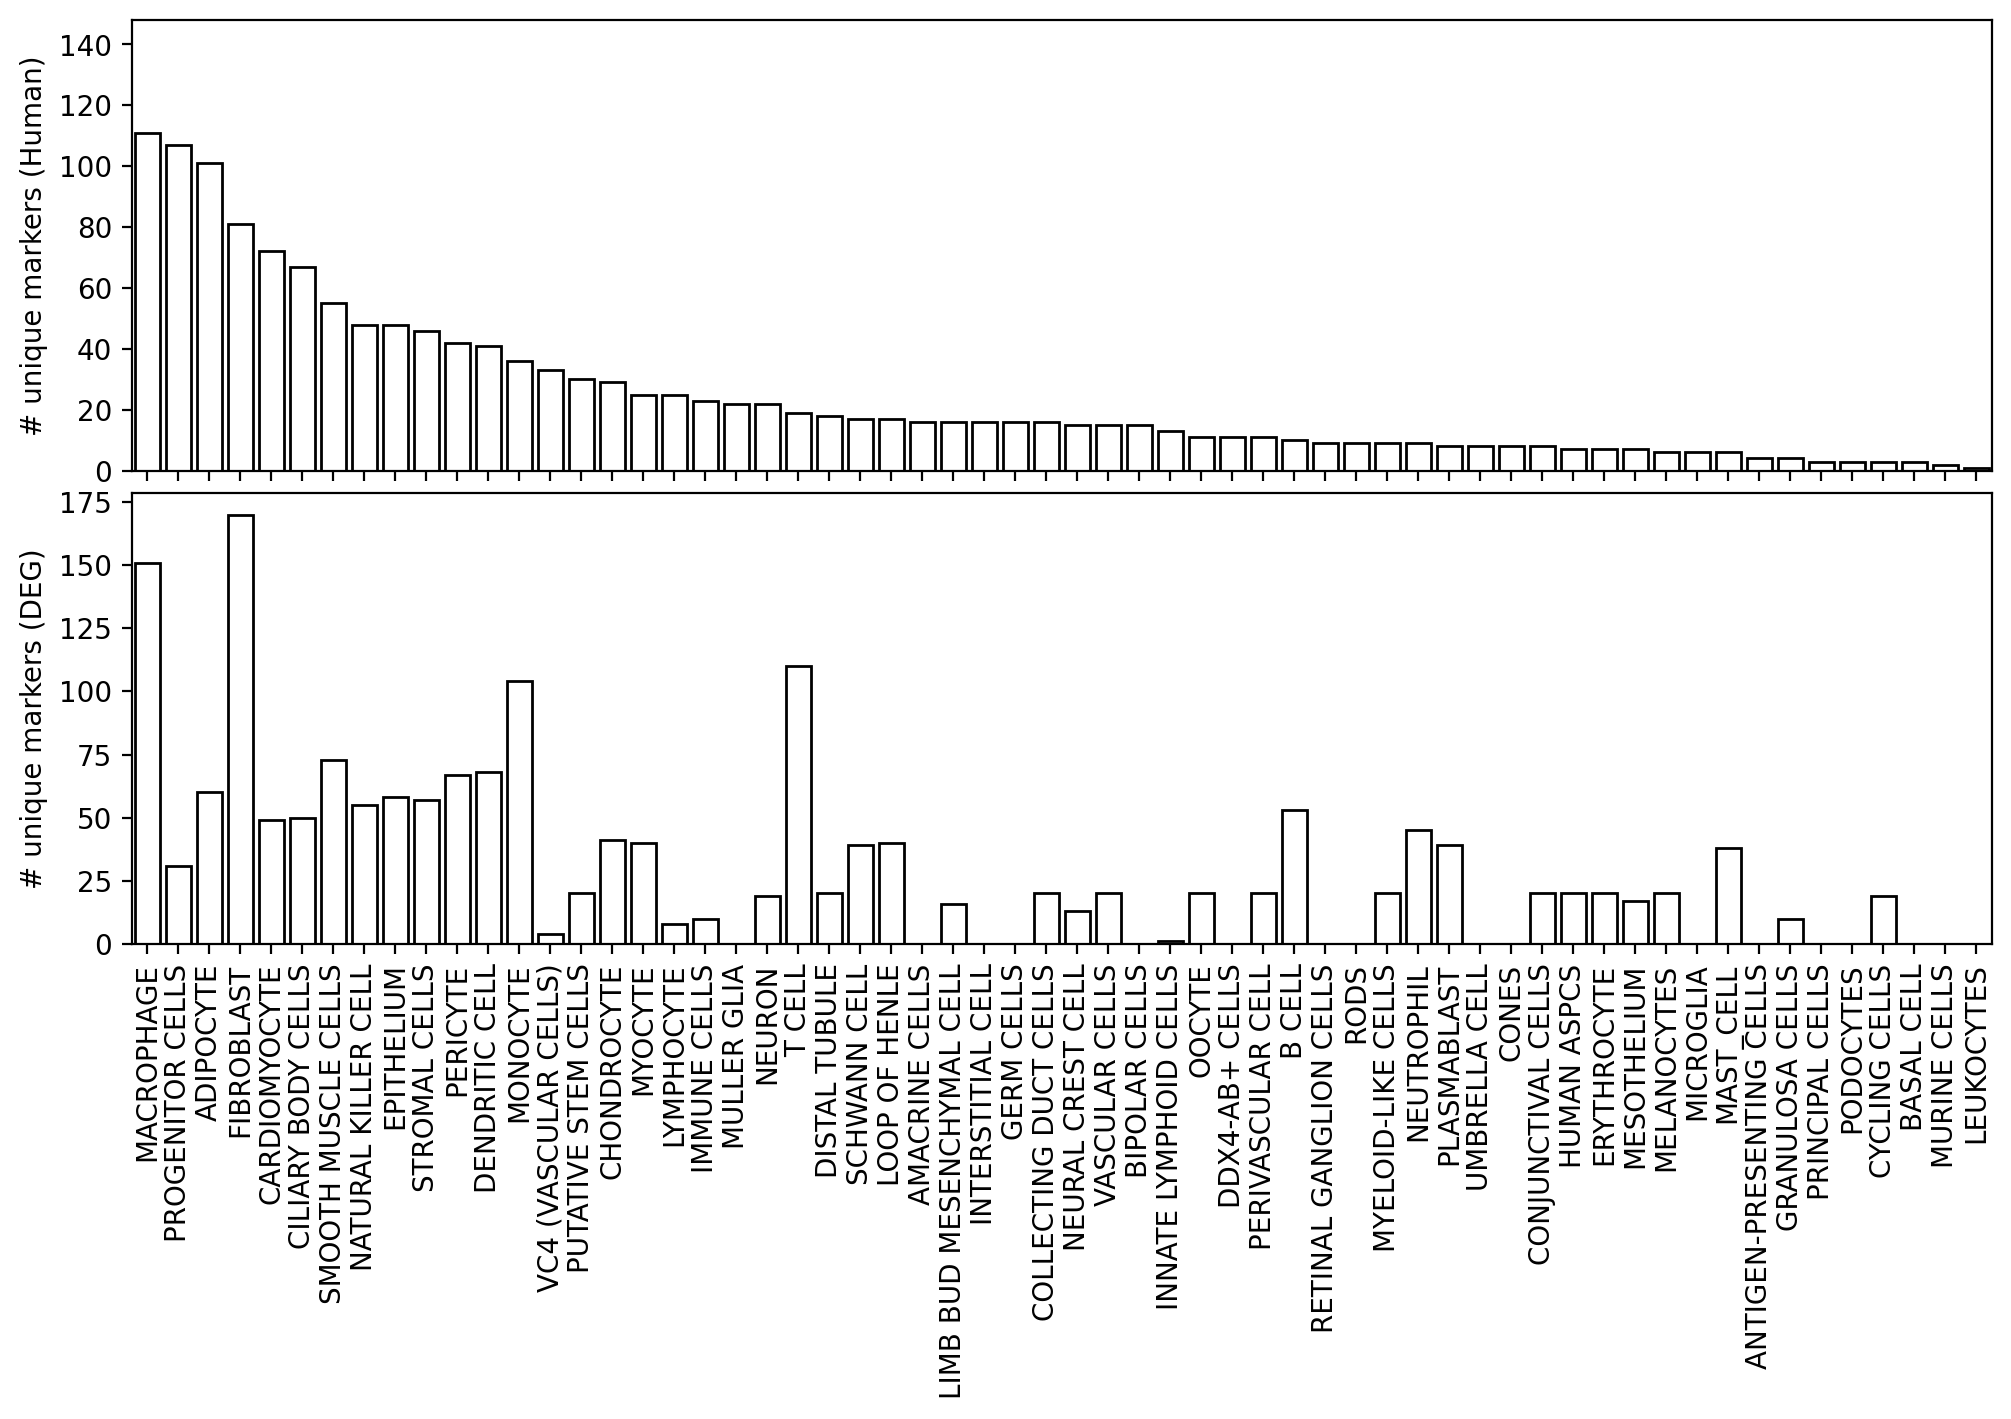

In [59]:
fig, axs = plt.subplots(figsize=(12,6), nrows=2, sharex=True)
fig.subplots_adjust(hspace=0.05)

ax = axs[0]
vals = hmn.groupby(["cell_type_id"])["feature_identifier"].nunique().sort_values(ascending=False)
x = vals.values
labels = vals.index
ax.bar(labels, x, edgecolor="k", facecolor="w")
ax.set(**{
    "xlim": (0.5, len(labels)-0.5),
    "ylabel": "# unique markers (Human)",
    # "xticklabels": []
})

ax = axs[1]
vals = deg.groupby(["cell_type_id"])["feature_identifier"].nunique().reindex(labels, fill_value=0)
x = vals.values
labels = vals.index
ax.bar(labels, x, edgecolor="k", facecolor="w")
ax.set(**{
    "xlim": (0.5, len(labels)-0.5),
    "ylabel": "# unique markers (DEG)",
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')
plt.show()

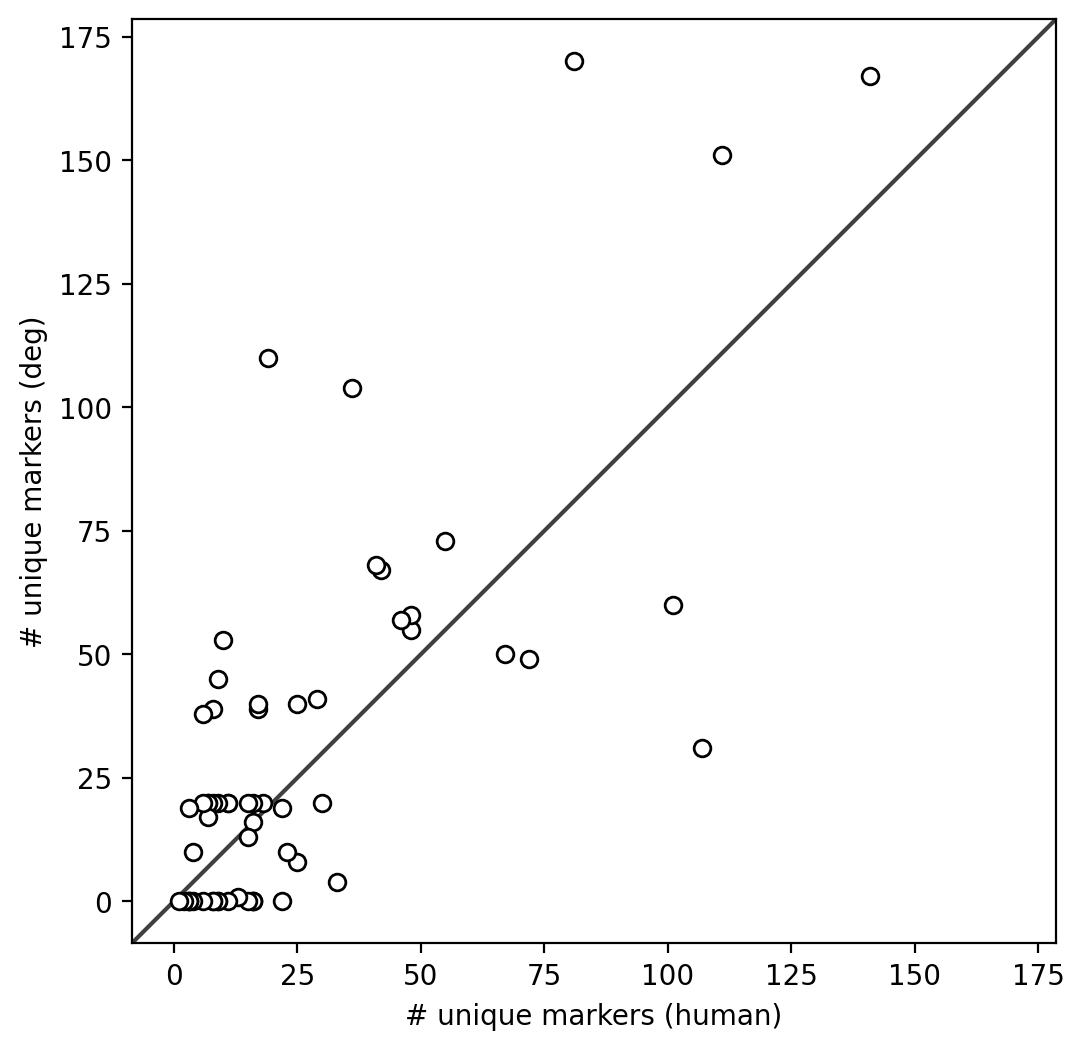

In [60]:
hmn_vals = hmn.groupby(["cell_type_id"])["feature_identifier"].nunique().sort_values(ascending=False)
deg_vals = deg.groupby(["cell_type_id"])["feature_identifier"].nunique().reindex(hmn_vals.index, fill_value=0)

fig, ax = plt.subplots(figsize=(6,6))

x = hmn_vals.values
y = deg_vals.values
ax.scatter(x, y, edgecolors="k", facecolors="w")
ax.set(**{
    "xlabel": "# unique markers (human)",
    "ylabel": "# unique markers (deg)",
})
yex(ax)
plt.show()

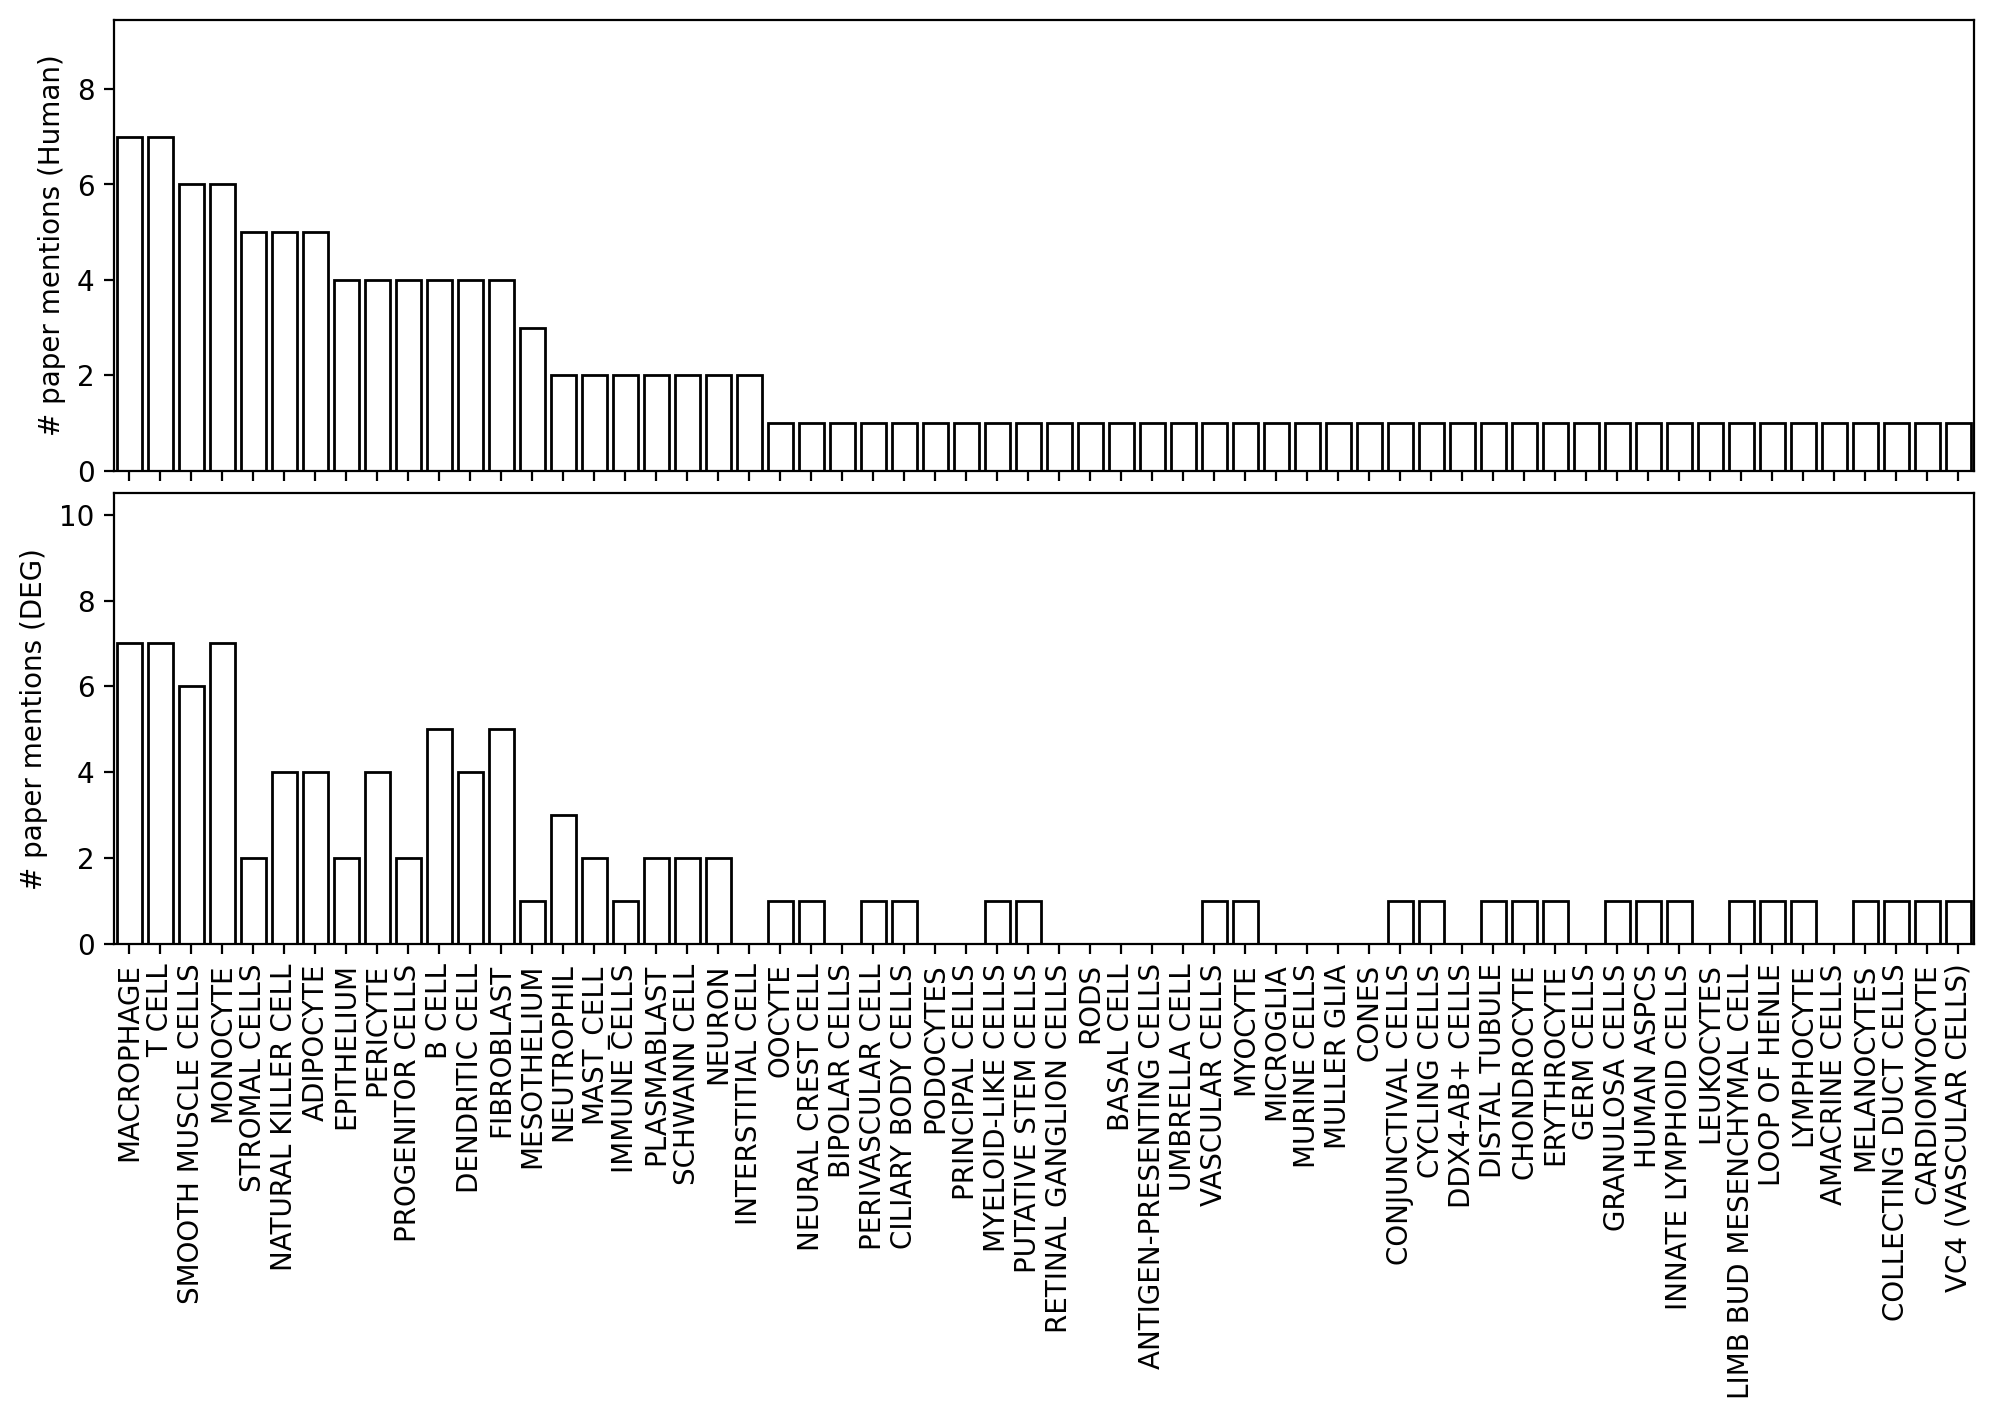

In [61]:
fig, axs = plt.subplots(figsize=(12,6), nrows=2, sharex=True)
fig.subplots_adjust(hspace=0.05)

ax = axs[0]
vals = hmn.groupby(["cell_type_id"])["ds_name"].nunique().sort_values(ascending=False)
x = vals.values
labels = vals.index
ax.bar(labels, x, edgecolor="k", facecolor="w")
ax.set(**{
    "xlim": (0.5, len(labels)-0.5),
    "ylabel": "# paper mentions (Human)",
    # "xticklabels": []
})

ax = axs[1]
vals = deg.groupby(["cell_type_id"])["ds_name"].nunique().reindex(labels, fill_value=0)
x = vals.values
labels = vals.index
ax.bar(labels, x, edgecolor="k", facecolor="w")
ax.set(**{
    "xlim": (0.5, len(labels)-0.5),
    "ylabel": "# paper mentions (DEG)",
})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, horizontalalignment='center')
plt.show()

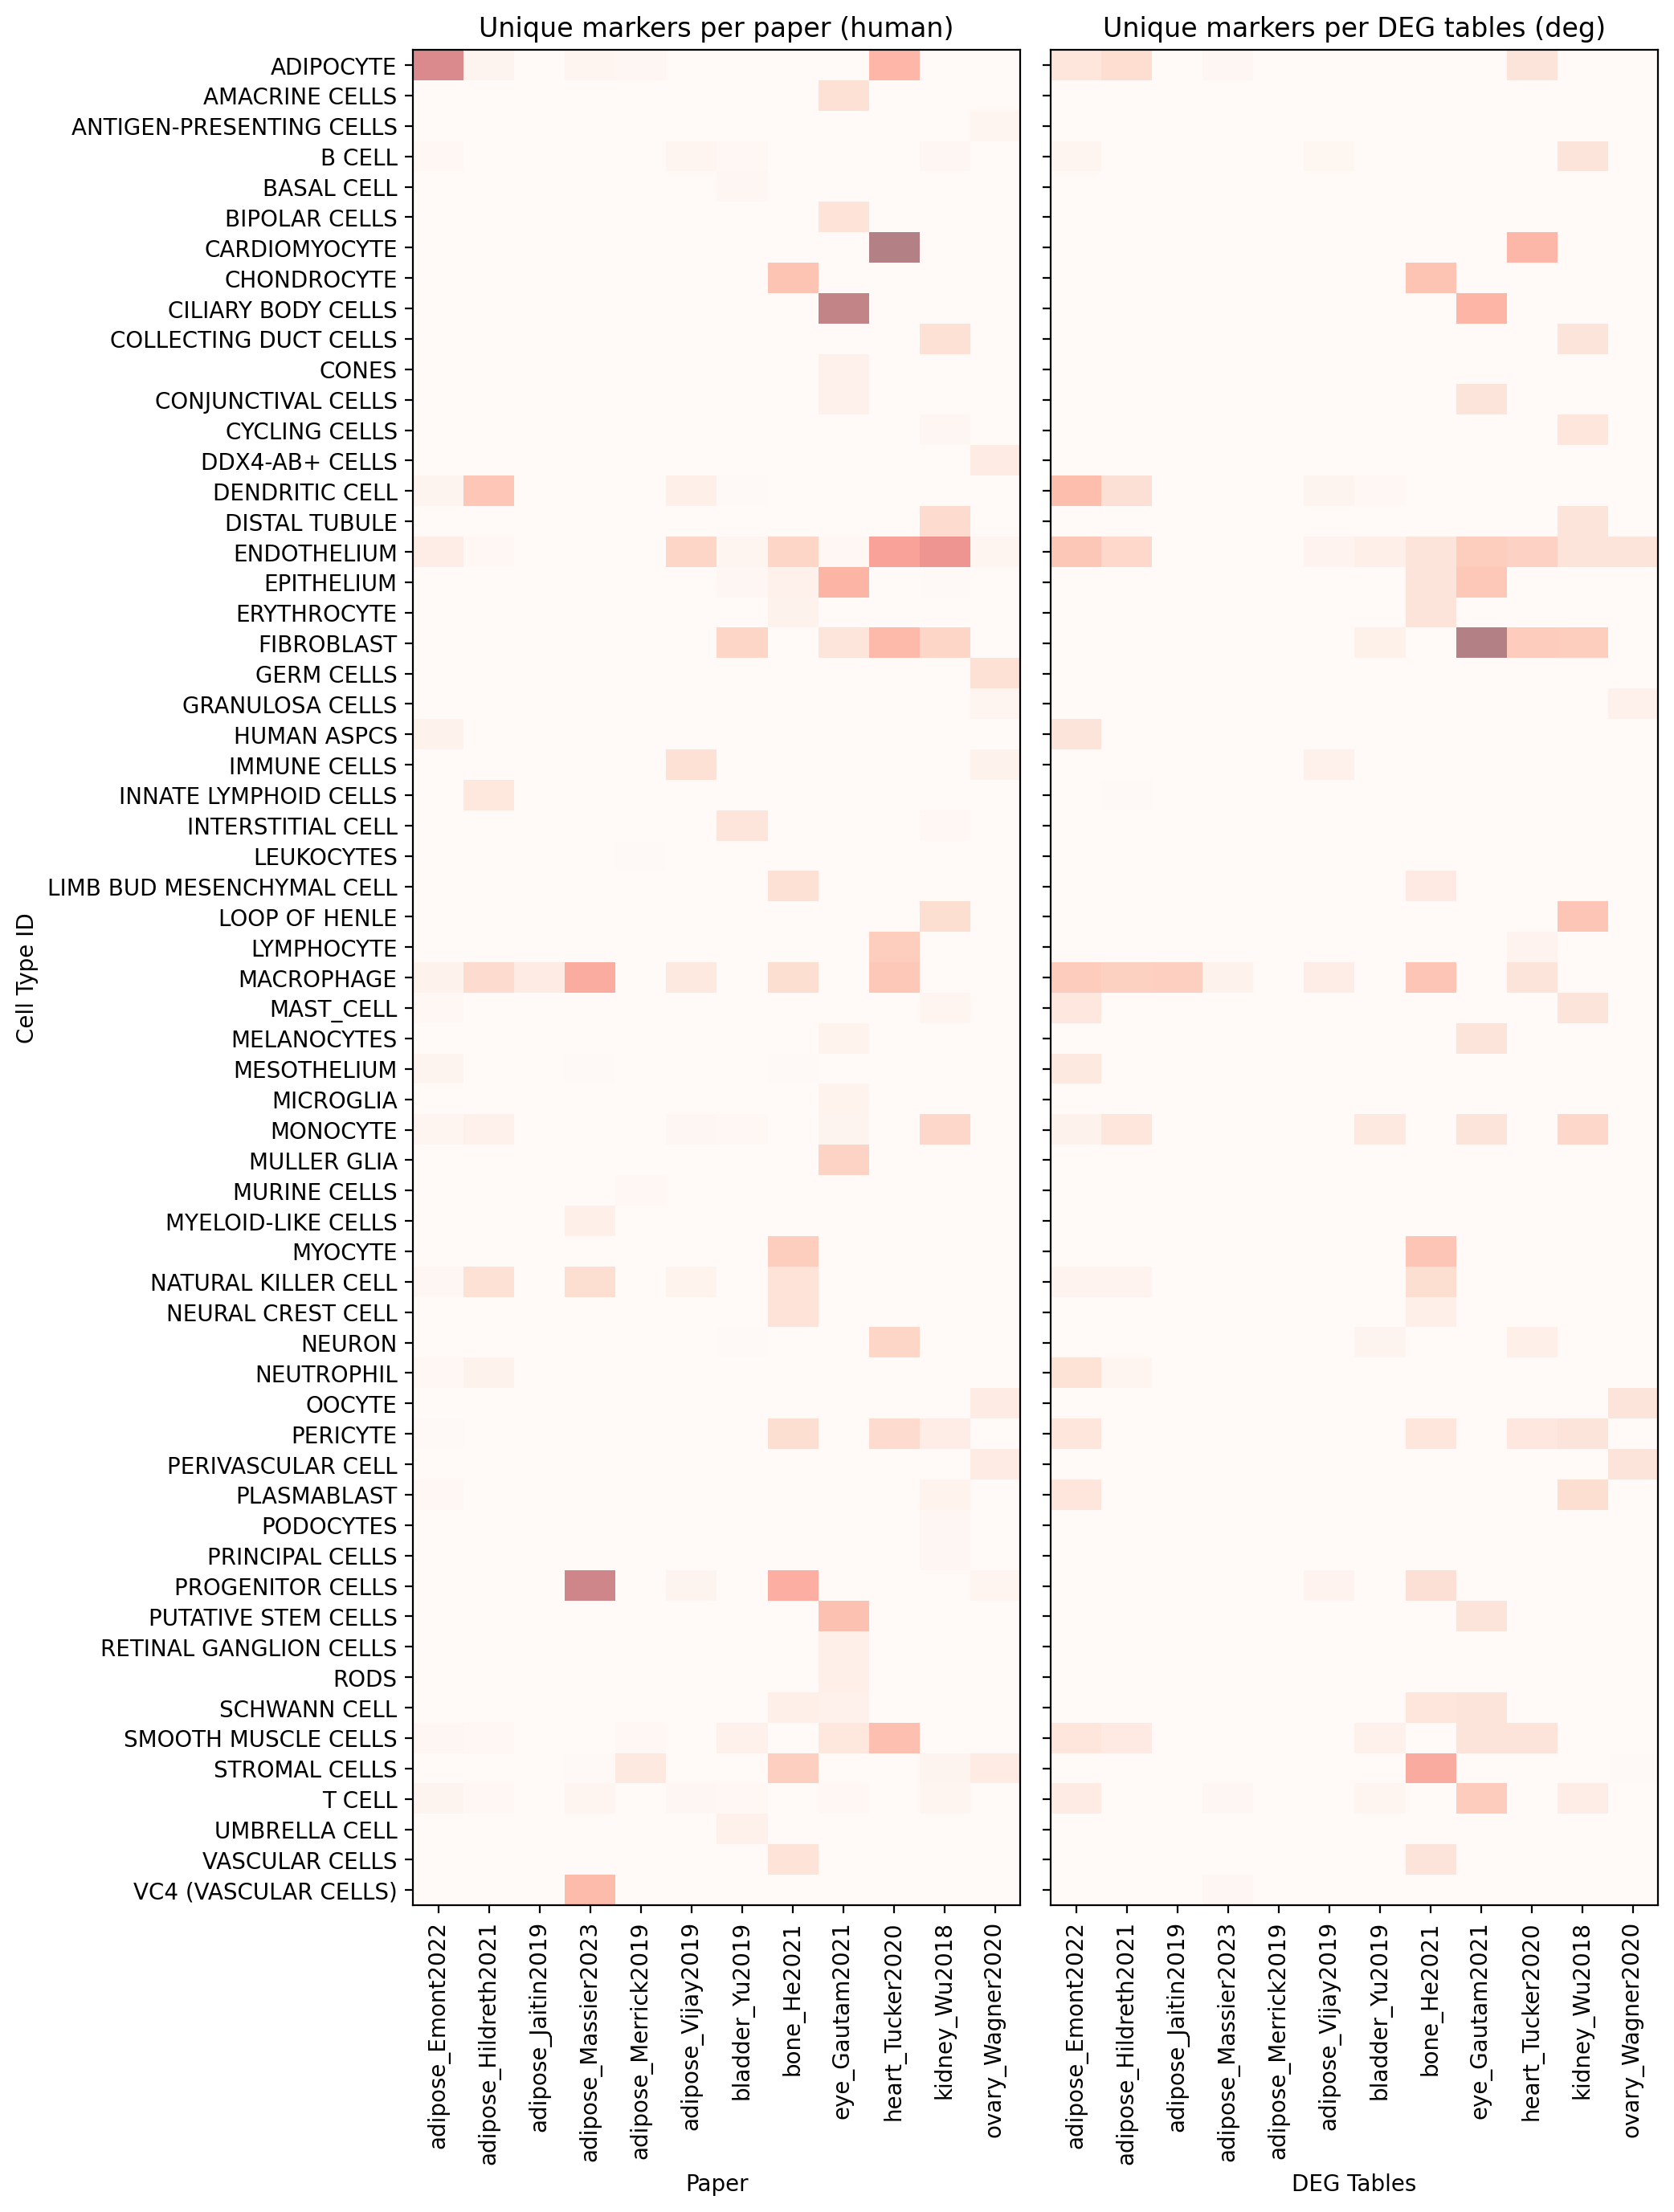

In [62]:
fig, axs = plt.subplots(figsize=(10, 15), ncols=2, sharey=True)
fig.subplots_adjust(wspace=0.05)
ax = axs[0]
tmp = hmn.groupby(["cell_type_id", "ds_name"])["feature_identifier"].nunique()
pvt = tmp.reset_index().pivot(index='cell_type_id', columns='ds_name', values='feature_identifier').fillna(0)

ax.imshow(pvt, cmap='Reds', alpha=0.5, aspect='auto')

ax.set(**{
    "ylabel": "Cell Type ID",
    "xlabel": "Paper",
    "xticklabels": pvt.columns,
    "yticklabels": pvt.index,
    "xticks": np.arange(len(pvt.columns)),
    "yticks": np.arange(len(pvt.index)),
    "title": "Unique markers per paper (human)",

})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')

ax = axs[1]
tmp = deg.groupby(["cell_type_id", "ds_name"])["feature_identifier"].nunique().reindex(tmp.index, fill_value=0).reset_index()
pvt = tmp.pivot(index='cell_type_id', columns='ds_name', values='feature_identifier').fillna(0)

ax.imshow(pvt, cmap='Reds', alpha=0.5, aspect='auto')

ax.set(**{
    "xlabel": "DEG Tables",
    # "ylabel": "Cell Type ID",
    "xticklabels": pvt.columns,
    "yticklabels": pvt.index,
    "xticks": np.arange(len(pvt.columns)),
    "yticks": np.arange(len(pvt.index)),
    "title": "Unique markers per DEG tables (deg)",

})
ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')

plt.show()

# Compare marker sets across papers/cell types

In [63]:
from itertools import product

In [199]:
ridx = list(product(deg.cell_type_id.unique(), deg.ds_name.unique()))

df = (
    deg.assign(present=1)
      .pivot_table(index=['cell_type_id', 'ds_name'], 
                   columns='feature_identifier', 
                   values='present', 
                   fill_value=0)
).reindex(ridx, fill_value=0)


In [200]:
mtx = df.values.reshape(
    df.index.get_level_values('cell_type_id').nunique(),
    df.index.get_level_values('ds_name').nunique(),
    -1
).astype(int)

In [229]:
from scipy.spatial.distance import jaccard
from scipy.spatial.distance import squareform, pdist

In [264]:
1-jaccard(np.array([0,0,0]), np.array([0,0,0]))

1

In [291]:
np.where(df.index.get_level_values('cell_type_id').unique() == "ADIPOCYTE")

(array([31]),)

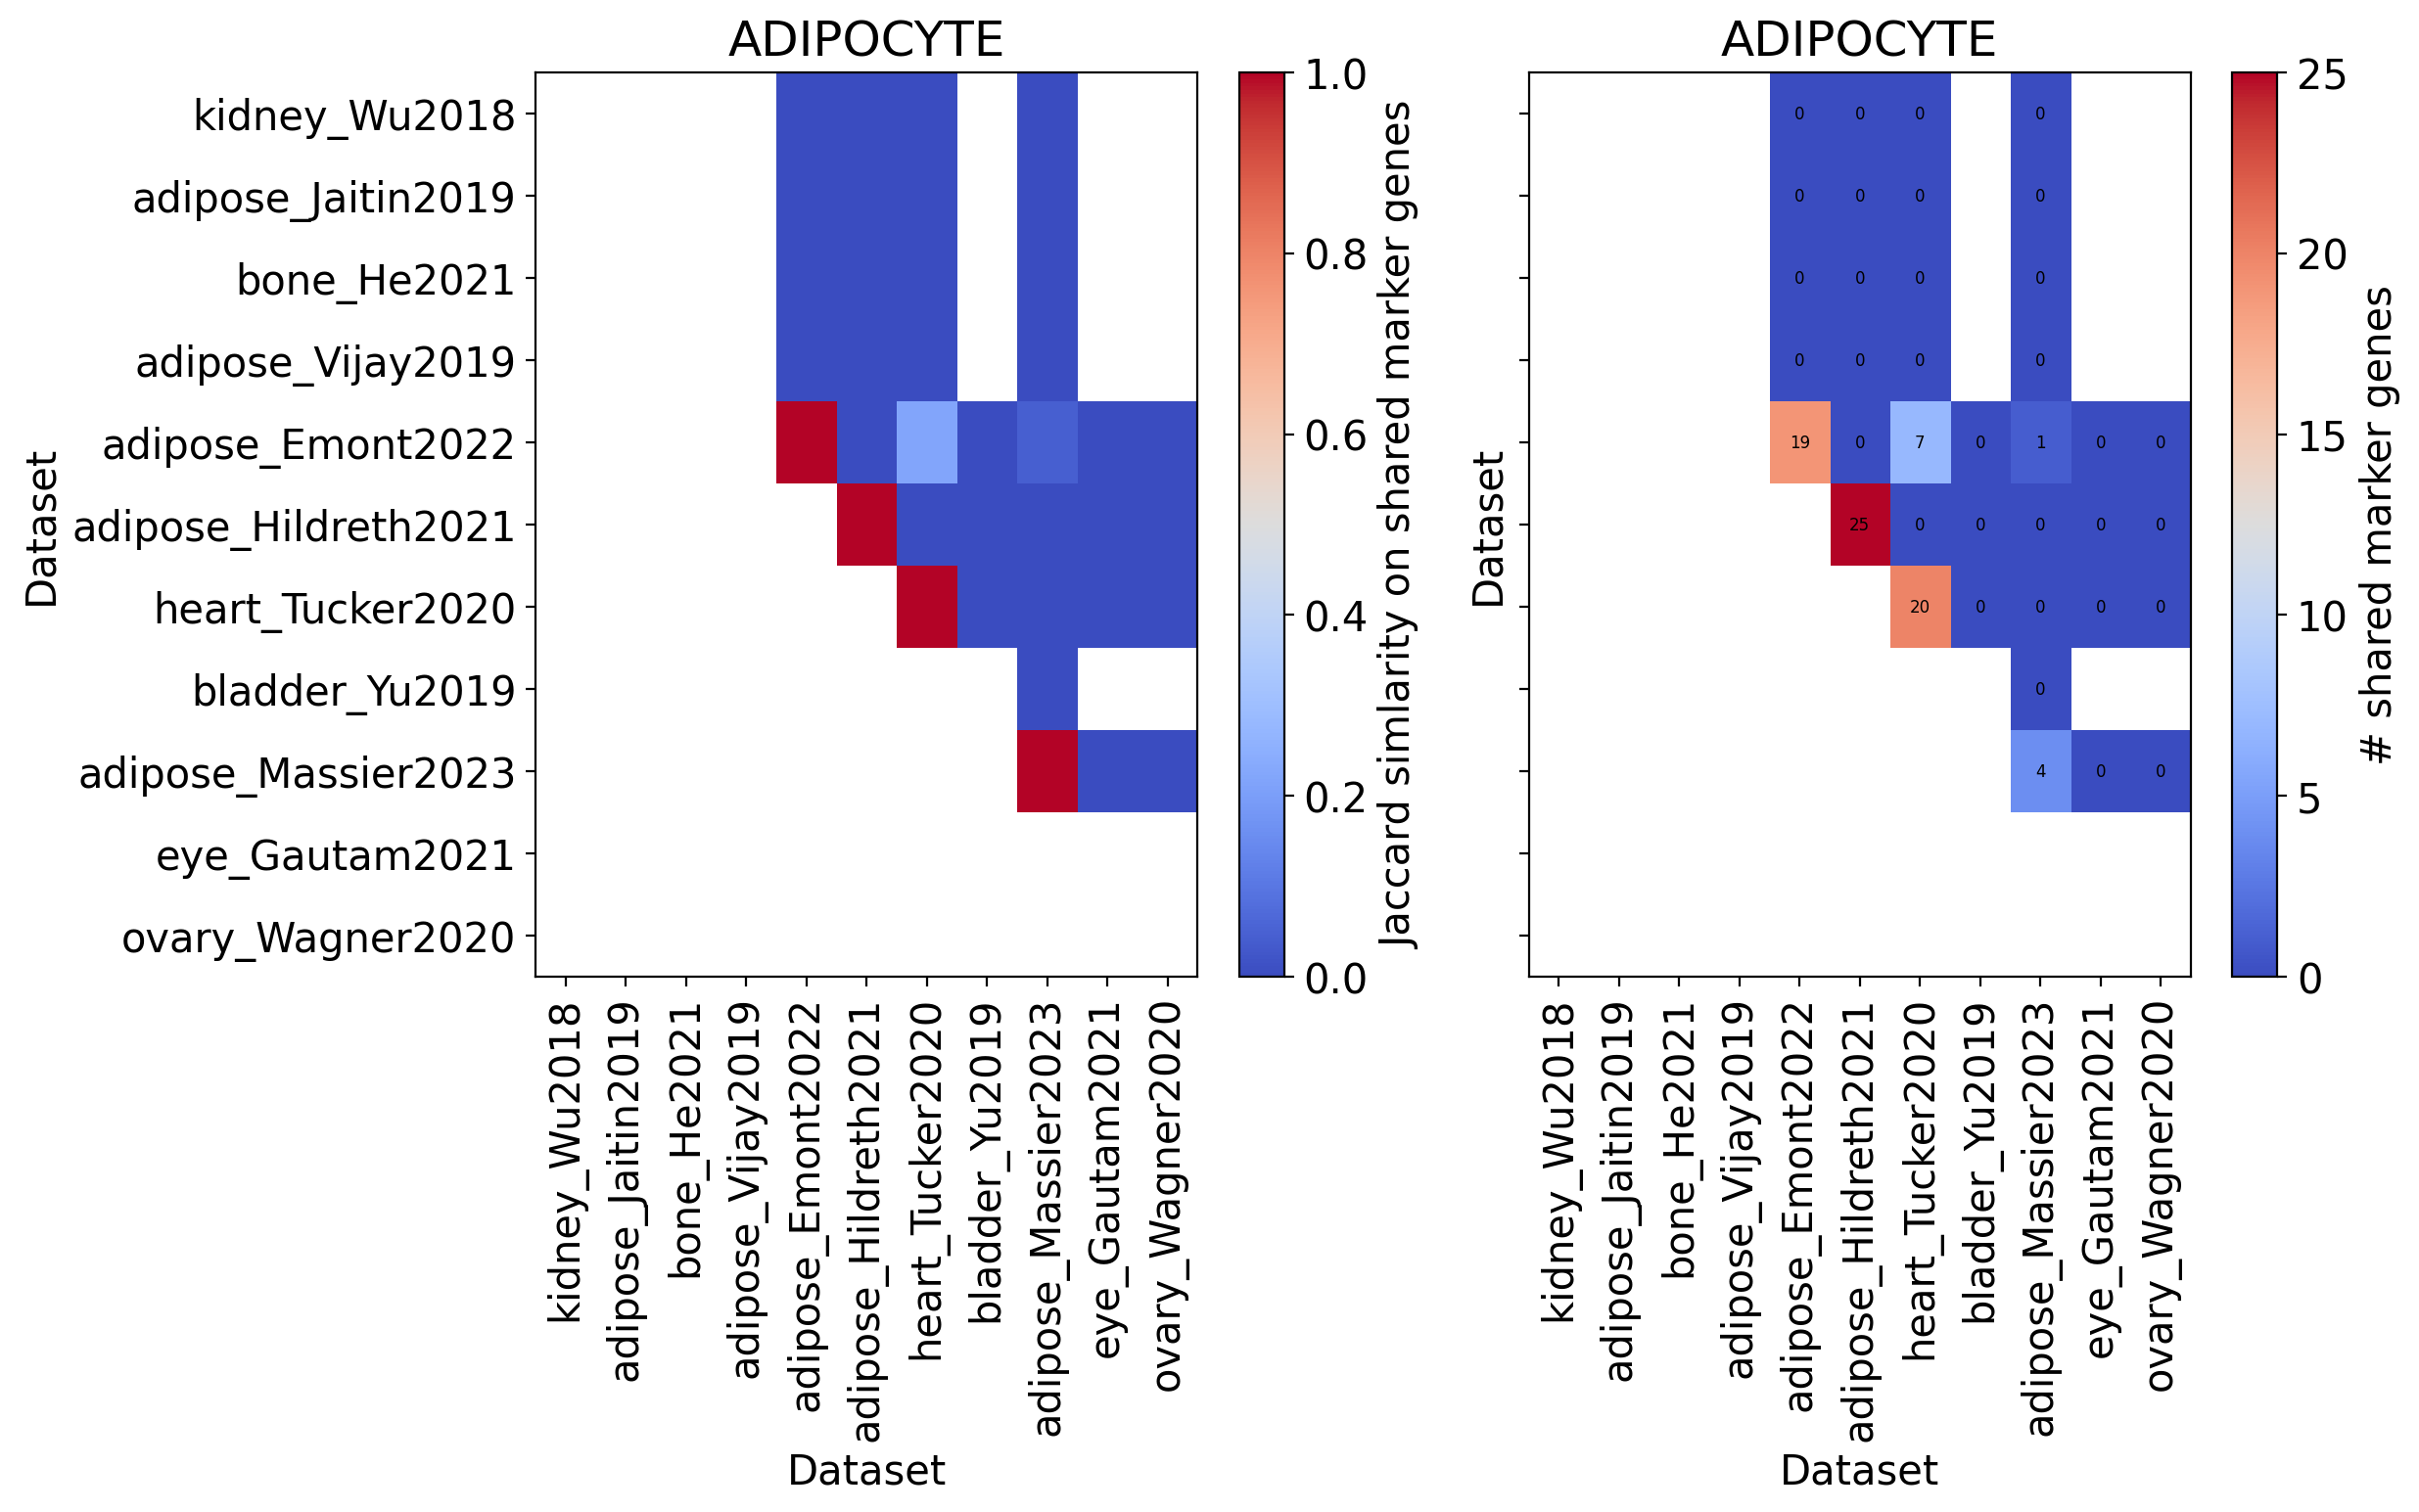

In [292]:
fig, axs = plt.subplots(figsize=(12,6), ncols=2, sharey=True)

ax = axs[0]
idx = 31

itx_counts = (mtx[idx] @ mtx[idx].T).astype(float)
# Calculate row sums (count of 1s in each row)
row_sums = mtx[idx].sum(axis=1)
# Calculate union counts using the formula |A ∪ B| = |A| + |B| - |A ∩ B|
# Broadcasting row_sums to create matrices of |A| and |B|
union_counts = row_sums[:, None] + row_sums[None, :] - itx_counts

x = squareform(1-pdist(mtx[idx], metric='jaccard'))
zidx = np.where(union_counts == 0)
x[np.diag_indices(x.shape[0])] = 1
x[zidx] = np.nan
x[np.tril_indices(x.shape[0], -1)] = np.nan

labels = df.index.get_level_values('ds_name').unique()

cax = ax.imshow(x, cmap='coolwarm', aspect='auto')#, vmin=0, vmax=1)
ax.set(**{
    "xlabel": "Dataset",
    "ylabel": "Dataset",
    "xticks": np.arange(len(labels)),
    "yticks": np.arange(len(labels)),
    "title": f"{df.index.get_level_values('cell_type_id').unique()[idx]}"
})
ax.set_xticklabels(labels, rotation=90, ha='center')
ax.set_yticklabels(labels, rotation=0, ha='right')
plt.colorbar(cax, ax=ax, label="Jaccard simlarity on shared marker genes")

ax = axs[1]

itx_counts = (mtx[idx] @ mtx[idx].T).astype(float)
x = itx_counts
x[zidx] = np.nan
x[np.tril_indices(x.shape[0], -1)] = np.nan

labels = df.index.get_level_values('ds_name').unique()

cax = ax.imshow(x, cmap='coolwarm', aspect='auto')#, vmin=0, vmax=1)

# print the numerical values
for i in range(len(labels)):
    for j in range(len(labels)):
        if np.isnan(x[i, j]):
            continue
        ax.text(j, i, int(x[i, j]), ha='center', va='center', color='k', fontsize=6)

ax.set(**{
    "xlabel": "Dataset",
    "ylabel": "Dataset",
    "xticks": np.arange(len(labels)),
    "yticks": np.arange(len(labels)),
    "title": f"{df.index.get_level_values('cell_type_id').unique()[idx]}"
})
ax.set_xticklabels(labels, rotation=90, ha='center')
ax.set_yticklabels(labels, rotation=0, ha='right')
plt.colorbar(cax, ax=ax, label="# shared marker genes")


plt.show()